<h1 style="text-align:center"><strong>Weather Data Analysis</strong></h1>

### **Introduction to the Weather Data Analysis Project**

Welcome to the Weather Data Analysis Project! This project aims to provide a comprehensive analysis of weather patterns and trends using historical data from the year 2023. By leveraging data from **[OpenMeteo.com](https://open-meteo.com/en/docs#current=temperature_2m&hourly=)**, we have gathered detailed weather information for various cities in India, with a particular focus on **Delhi** and **Chennai**. The project is designed to help users understand and visualize key weather metrics such as temperature, humidity, sunshine duration, daylight duration, and sunrise/sunset times.

Weather data analysis is crucial for a variety of applications, including urban planning, agriculture, disaster management, and even personal decision-making. By analyzing this data, we can identify trends, make predictions, and gain insights into how weather conditions vary across different regions and time periods.

This project is structured around **few problem statements**, each addressing a specific aspect of weather data analysis. These problem statements are designed to explore different dimensions of weather data, from day-wise temperature variations to the relationship between temperature and humidity, and from sunshine duration to sunrise and sunset times. Below is a brief overview of the problem statements:


### **Problem Statements**

1. **What were the day-wise temperature variations for any given month in Delhi during 2023?**  

2. **What were the average monthly temperatures in Delhi throughout 2023?**  

3. **How do the average yearly temperatures compare across different cities in India?**  

4. **What is the relationship between temperature and humidity in Delhi during 2023?**  

5. **What is the relationship between temperature and humidity in Chennai during 2023?**  

6. **How did sunshine and daylight durations vary in Delhi throughout 2023?**  

7. **How did sunshine and daylight durations vary in Chennai throughout 2023?**  

8. **What were the sunrise and sunset times for each day in Delhi during 2023?**  

9. **What were the sunrise and sunset times for each day in Chennai during 2023?**  

10. **What were the maximum and minimum temperatures recorded each month in Delhi during 2023?**  

11. **What were the maximum and minimum temperatures recorded each month in Chennai during 2023?**  

---

### **Objectives of the Project**

- To visualize weather trends and patterns using graphs and charts.
- To compare weather conditions between different cities and time periods.
- To analyze the relationship between various weather parameters (e.g., temperature and humidity).
- To help users gain insights into how weather conditions change over time.

---

### **Tools and Technologies Used**

- **Data Source**: OpenMeteo.com API
- **Programming Language**: Python
- **Libraries**: Pandas, Matplotlib, numpy, Requests
- **Visualization**: Line plots, bar charts, scatterplots, and more.

---


### **Importing Libraries and Cleaning data**

In [43]:
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

BASE_URL="https://archive-api.open-meteo.com/v1/archive?latitude=28.6519&longitude=77.2315&start_date=2023-01-01&end_date=2023-12-31&daily=temperature_2m_mean&timezone=Asia%2FBangkok"
data = requests.get(BASE_URL).json()

df = pd.DataFrame(data)

print(df.info)
print(df.isna().sum())



<bound method DataFrame.info of                       latitude  longitude  generationtime_ms  \
time                 28.646748    77.2748           0.182867   
temperature_2m_mean  28.646748    77.2748           0.182867   

                     utc_offset_seconds      timezone timezone_abbreviation  \
time                              25200  Asia/Bangkok                 GMT+7   
temperature_2m_mean               25200  Asia/Bangkok                 GMT+7   

                     elevation daily_units  \
time                     231.0     iso8601   
temperature_2m_mean      231.0          °C   

                                                                 daily  
time                 [2023-01-01, 2023-01-02, 2023-01-03, 2023-01-0...  
temperature_2m_mean  [12.1, 11.7, 9.9, 9.5, 8.7, 8.1, 7.7, 9.5, 10....  >

### **Extraction of valuable data and initializations**

In [29]:
# daily data extraction
dates = np.array(data['daily']['time'])
daily_temp = np.array(data['daily']['temperature_2m_mean'])

# monthly data extraction
def extractMonthData(startDate, endDate):
        month = np.logical_and(dates >= startDate,dates <= endDate)
        return daily_temp[np.where(month)]

monthlyData = {
        "january": extractMonthData("2023-01-01", "2023-01-31"),
        "february": extractMonthData("2023-02-01", "2023-02-28"),
        "march": extractMonthData("2023-03-01", "2023-03-31"),
        "april": extractMonthData("2023-04-01", "2023-04-30"),
        "may": extractMonthData("2023-05-01", "2023-05-31"),
        "june": extractMonthData("2023-06-01", "2023-06-30"),
        "july": extractMonthData("2023-07-01", "2023-07-31"),
        "august": extractMonthData("2023-08-01", "2023-08-31"),
        "september": extractMonthData("2023-09-01", "2023-09-30"),
        "october": extractMonthData("2023-10-01", "2023-10-31"),
        "november": extractMonthData("2023-11-01", "2023-11-30"),
        "december": extractMonthData("2023-12-01", "2023-12-31"),
}


monthlyAvg = {
        "january": np.mean(monthlyData["january"]).round(3),
        "february": np.mean(monthlyData["february"]).round(3),
        "march": np.mean(monthlyData["march"]).round(3),
        "april": np.mean(monthlyData["april"]).round(3),
        "may": np.mean(monthlyData["may"]).round(3),
        "june": np.mean(monthlyData["june"]).round(3),
        "july": np.mean(monthlyData["july"]).round(3),
        "august": np.mean(monthlyData["august"]).round(3),
        "september": np.mean(monthlyData["september"]).round(3),
        "october": np.mean(monthlyData["october"]).round(3),
        "november": np.mean(monthlyData["november"]).round(3),
        "december": np.mean(monthlyData["december"]).round(3)
}

startTime = [
        "2023-01-01T00:00",  # jan
        "2023-02-01T00:00",  # feb
        "2023-03-01T00:00",  # march
        "2023-04-01T00:00",  # april
        "2023-05-01T00:00",  # may
        "2023-06-01T00:00",  # june
        "2023-07-01T00:00",  # july
        "2023-08-01T00:00",  # aug
        "2023-09-01T00:00",  # sept
        "2023-10-01T00:00",  # oct
        "2023-11-01T00:00",  # nov
        "2023-12-01T00:00"   # dec
]

endTime = [
        "2023-01-31T23:00",  # jan
        "2023-02-28T23:00",  # feb
        "2023-03-31T23:00",  # march
        "2023-04-30T23:00",  # april
        "2023-05-31T23:00",  # may
        "2023-06-30T23:00",  # june
        "2023-07-31T23:00",  # july
        "2023-08-31T23:00",  # aug
        "2023-09-30T23:00",  # sept
        "2023-10-31T23:00",  # oct
        "2023-11-30T23:00",  # nov
        "2023-12-31T23:00"   # decS
]


# **Visualizations as per problem statements**

## **a. Day-wise Temperatures of any Month in Delhi**

Enter month:  june


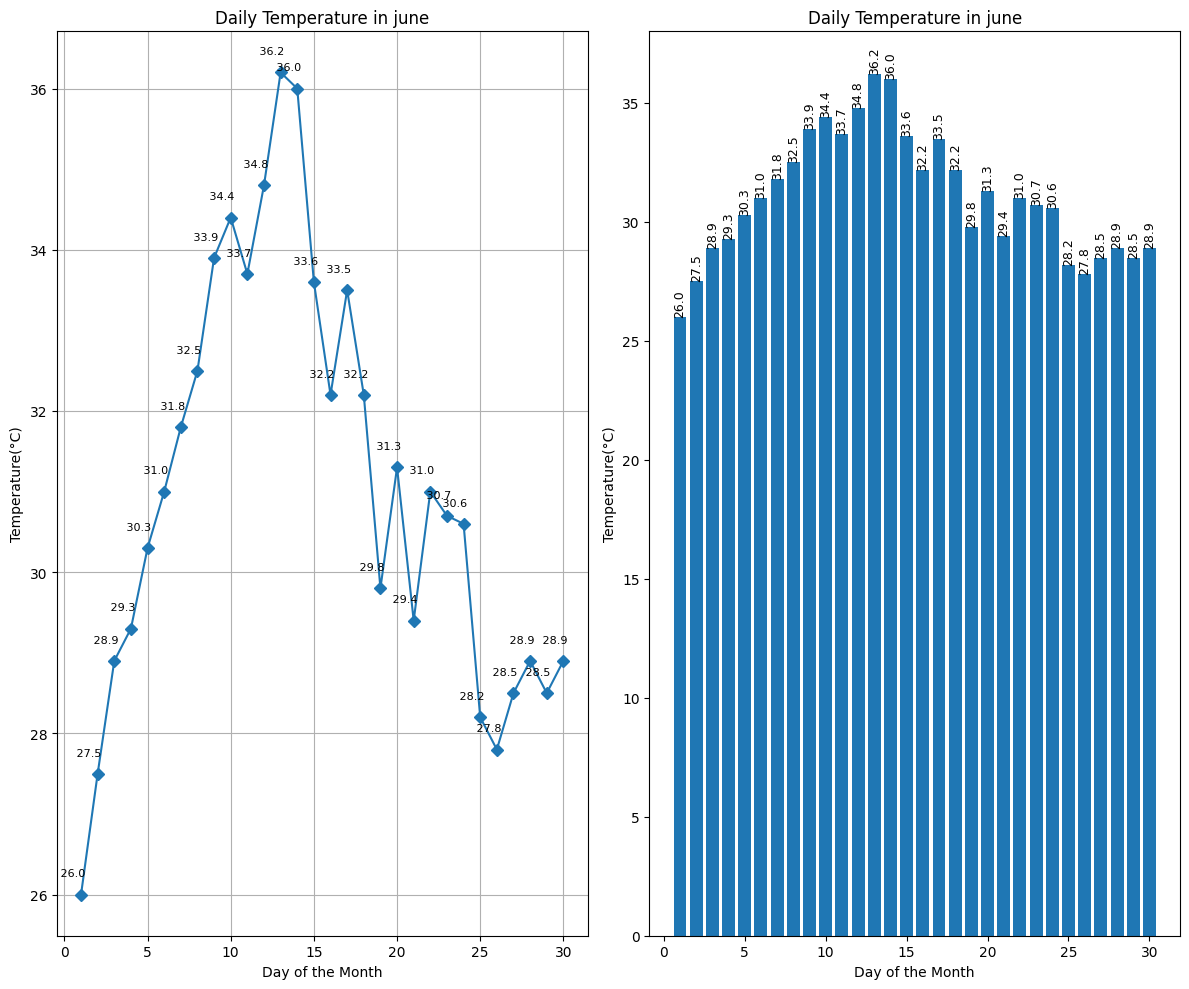

In [20]:
def chooseMonth():
    month = input("Enter month: ").lower()
    monthData = monthlyData[month]

    createChart(month, monthData.size, monthData)

def createChart(month,x,y):
    days = np.arange(1,x+1)

    fig, axs = plt.subplots(1, 2, figsize=(12, 10))
    axs[0].plot(days, y,marker="D")
    axs[0].grid()
    

    axs[0].set_xlabel("Day of the Month")
    axs[0].set_ylabel("Temperature(°C)")
    axs[0].set_title(f"Daily Temperature in {month}")
    for a, b in zip(days, y):
        axs[0].text(a-0.5, b+0.2, f" {b} ", fontsize=8, ha="center", va="bottom")

    barplot = axs[1].bar(days,y)
    axs[1].set_xlabel("Day of the Month")
    axs[1].set_ylabel("Temperature(°C)")
    axs[1].set_title(f"Daily Temperature in {month}")
    axs[1].bar_label(barplot, labels=y, rotation=90, fontsize=9)


    plt.tight_layout()
    plt.show()

chooseMonth()

## **b. Average Monthly Temperatures in Delhi**

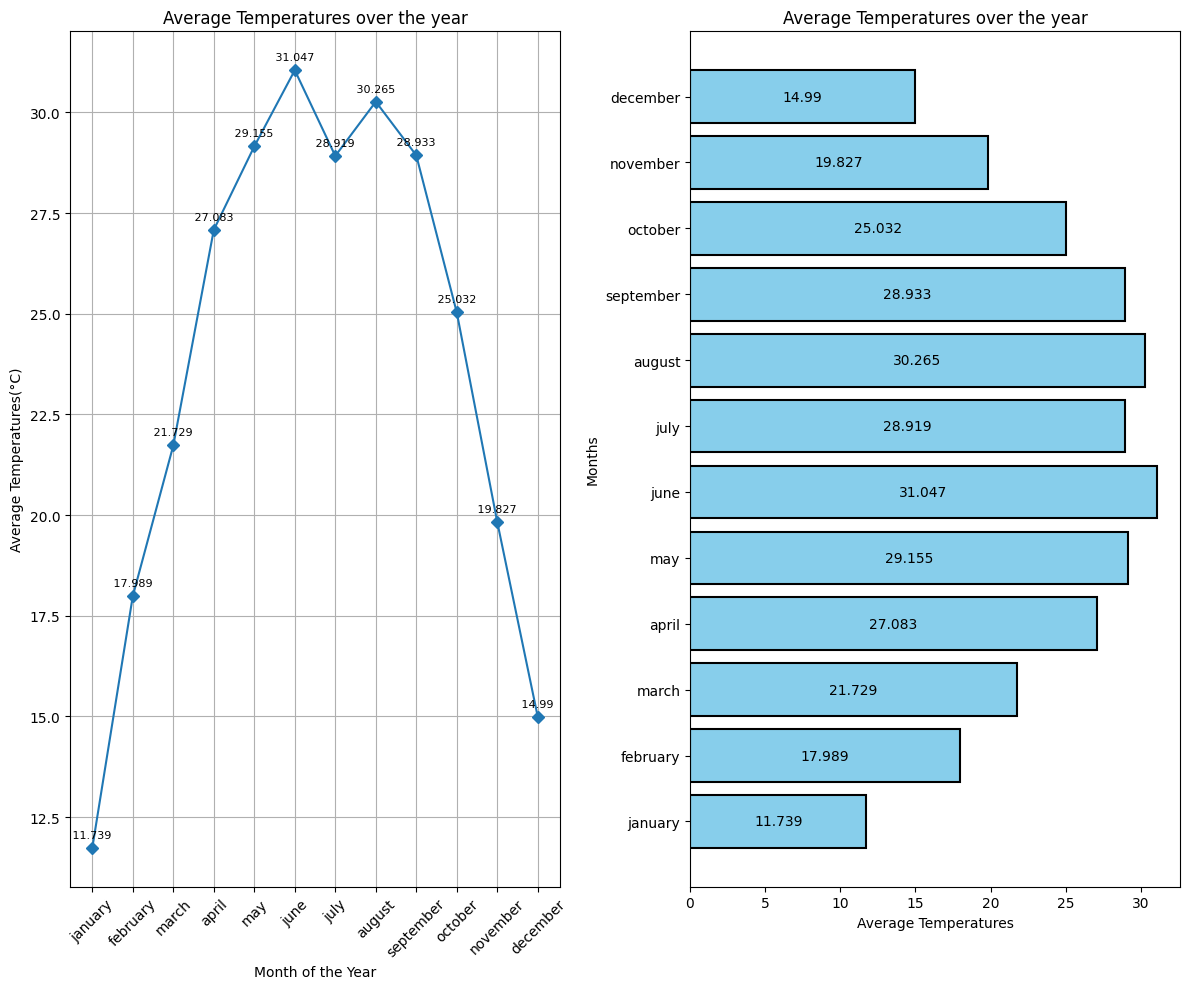

In [21]:
def createAverageChart(monthAvg):
    months = np.array(list(monthAvg.keys()))
    avgs = np.array(list(monthAvg.values()))

    fig, axs = plt.subplots(1,2, figsize=(12, 10))
    axs[0].plot(months, avgs, marker="D")
    axs[0].grid()

    axs[0].set_xlabel("Month of the Year")
    axs[0].set_ylabel("Average Temperatures(°C)")
    axs[0].set_title(f"Average Temperatures over the year")
    axs[0].tick_params(axis="x",rotation=45)
    for a, b in zip(months, avgs):
        axs[0].text(a, b+0.2, f" {b} ", fontsize=8, ha="center", va="bottom")

    barplot = axs[1].barh(months,avgs, color="skyblue", linewidth=1.5, edgecolor="black")
    axs[1].set_xlabel("Average Temperatures")
    axs[1].set_ylabel("Months")
    axs[1].set_title(f"Average Temperatures over the year")
    axs[1].bar_label(barplot, labels=avgs, label_type="center")


    
    plt.tight_layout()
    plt.show()

createAverageChart(monthlyAvg)

### **Delhi's Monthly Average Temperatures (°C) - 2023**  
- **Hottest Month**: **June (31.05°C)**  
- **Coldest Month**: **January (11.74°C)**  

#### **Temperature Trends**:  
- **Winter (Dec - Feb)**: **Cold**, temperatures between **11.74°C - 19.83°C**.  
- **Spring (Mar - May)**: **Rapid increase**, peaking at **29.16°C** in May.  
- **Summer (Jun - Aug)**: **Hottest period**, June records the highest temperature at **31.05°C**.  
- **Monsoon (Sep - Oct)**: **Gradual cooling**, around **25-29°C**.  
- **Post-Monsoon & Winter Transition (Nov - Dec)**: **Sharp decline**, dropping to **14.99°C** by December.  

## **c. Average Yearly Temperatures for different cities in India**

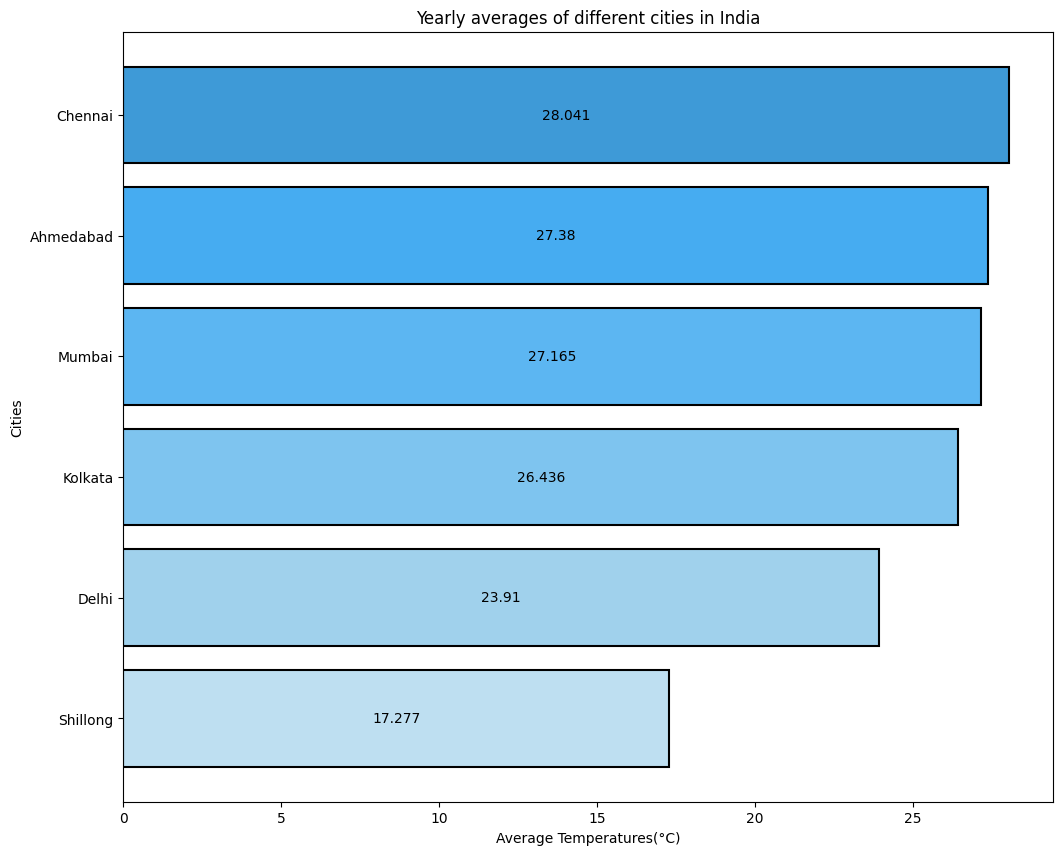

<Figure size 640x480 with 0 Axes>

In [22]:
def cityAverageTemperatures():
    def createAverageChart(city,avg):

        colors = ["#BEDFF1","#A0D1EC","#7EC4EF","#5CB6F2","#46ACF1","#3E9AD7"]
        fig, axs = plt.subplots(1, 1, figsize=(12, 10))

        barplot = axs.barh(city,avg, color=colors, linewidth=1.5, edgecolor="black")
        axs.set_xlabel("Average Temperatures(°C)")
        axs.set_ylabel("Cities")
        axs.set_title(f"Yearly averages of different cities in India")
        axs.bar_label(barplot, labels=avg, label_type="center")


        plt.show()
        plt.tight_layout()

    # BASE_URL = "https://archive-api.open-meteo.com/v1/archive?latitude=28.6519&longitude=77.2315&start_date=2023-01-01&end_date=2023-12-31&daily=temperature_2m_  mean&timezone=Asia%2FBangkok"

    BASE_URL = "https://archive-api.open-meteo.com/v1/archive?"

    # delhi, mumbai, chennai, kolkata, ahmedabad, shillong
    cities = ["Delhi","Mumbai", "Chennai", "Kolkata", "Ahmedabad", "Shillong"]

    lat = [28.6519,19.0728,13.0878,22.5626,23.0258,25.5689]

    lon = [77.2315,72.8826,80.2785,88.363,72.5873,91.8831]

    startDate = "2023-01-01"
    endDate = "2023-12-31"

    avgs = []

    for i in range(len(lat)):
        url = f"{BASE_URL}latitude={lat[i]}&longitude={lon[i]}&start_date={startDate}&end_date={endDate}&daily=temperature_2m_mean&timezone=Asia%2FBangkok"

        data = requests.get(url).json()
        daily_temp = np.array(data['daily']['temperature_2m_mean'])
        yearly_avg = np.mean(daily_temp).round(3)
        avgs.append(yearly_avg)

    avg_arr = np.array(avgs)
    city = np.array(cities)

    sorted = np.argsort(avg_arr)

    avg_arr = avg_arr[sorted]
    city = city[sorted]

    # print(city, avg_arr)
    createAverageChart(city, avg_arr)

cityAverageTemperatures()

### **Observations:**  
- **Chennai is the hottest** city on this list, having the highest average temperature.  
- **Shillong is significantly cooler**, reflecting its hill station climate.  
- **Delhi has a lower yearly average** compared to coastal cities due to extreme seasonal variations.  
- **Ahmedabad, Mumbai, and Kolkata are close in average temperatures**, with Mumbai being slightly cooler due to coastal influence.  

## **d. Scatterplot between Temperature and Humidity for Delhi(2023)**

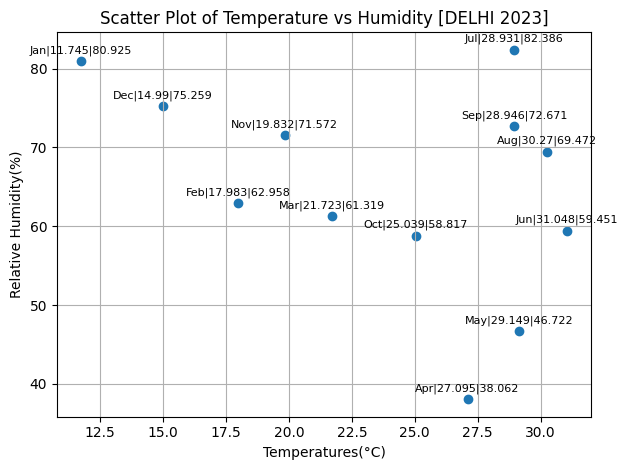

In [30]:
def createScatterPlot(x,y, city):
    xValues = x
    yValues = y
    months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
    # print(xValues, yValues)

    for i,(a,b) in enumerate(zip(xValues, yValues)):
        plt.text(a,b+1,f"{months[i]}|{a}|{b}", fontsize=8, ha="center")
    
    plt.scatter(xValues, yValues, marker="o")
    plt.xlabel("Temperatures(°C)")
    plt.ylabel("Relative Humidity(%)")
    plt.title(f"Scatter Plot of Temperature vs Humidity [{city} 2023]")

    plt.grid()
    plt.tight_layout()
    plt.show()

def scatterplotDelhi():
    
    url = "https://archive-api.open-meteo.com/v1/archive?latitude=28.6519&longitude=77.2315&start_date=2023-01-01&end_date=2023-12-31&hourly=temperature_2m,relative_humidity_2m&timezone=Asia%2FBangkok"
    response = requests.get(url).json()
    df = pd.DataFrame(response["hourly"])
    # checkData(df)

    tempWithHumidity = {}

    for i in range(len(endTime)):
        monthLogic = (df["time"] >= startTime[i]) & (df["time"] <= endTime[i])
        monthData = df[monthLogic][["temperature_2m","relative_humidity_2m"]]

        stats = monthData.describe().round(3)
        temp = stats.loc["mean", "temperature_2m"]
        humid = stats.loc["mean", "relative_humidity_2m"]
        tempWithHumidity[temp] = humid

        # print(stats.loc["mean", "temperature_2m"])
        # print(stats.loc["mean", "relative_humidity_2m"])

    return tempWithHumidity



x = np.array(list(scatterplotDelhi().keys()))
y = np.array(list(scatterplotDelhi().values()))

createScatterPlot(x,y, "DELHI")


### **Delhi 2023: Temperature vs. Humidity Insights**  

- **Winter (Dec-Jan):** **Low temperatures (~12-15°C) with high humidity (75-81%)**, indicating cold and moist conditions.  
- **Spring (Feb-Mar):** **Gradual temperature rise (~18-22°C) with decreasing humidity (~63-61%)**, showing a shift towards drier weather.  
- **Summer (Apr-Jun):** **Peak temperatures (~27-31°C) with humidity dropping to ~38-59%**, with **May being the driest month (~47%)**.  
- **Monsoon (Jul-Sep):** **High humidity (~69-82%) despite temperatures staying high (~28-30°C)**, marking the rainy season. **July is the most humid (~82%)**.  
- **Autumn (Oct-Nov):** **Temperatures fall (~25-19°C) with humidity increasing (~59-72%)**, signaling a return to cooler and wetter conditions.  

### **Key Takeaways:**  
- **Inverse relation:** As temperatures rise (Apr-May), humidity drops.  
- **Monsoon peak:** July shows the highest humidity (~82%).  
- **Transition months:** March & October mark seasonal humidity-temperature shifts.  


## **e. Scatterplot between Temperature and Humidity for Chennai(2023)**

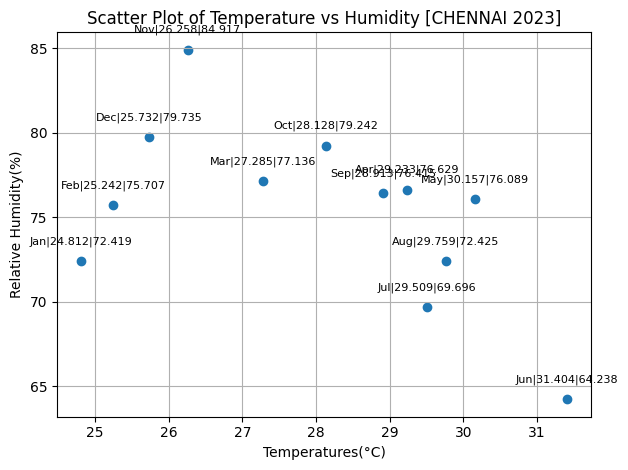

In [32]:
def scatterplotChennai():
    
    url = "https://archive-api.open-meteo.com/v1/archive?latitude=13.0878&longitude=80.2785&start_date=2023-01-01&end_date=2023-12-31&hourly=temperature_2m,relative_humidity_2m&timezone=Asia%2FBangkok"

    response = requests.get(url).json()
    df = pd.DataFrame(response["hourly"])
    # checkData(df)

    tempWithHumidity = {}

   
    for i in range(len(endTime)):
        monthLogic = (df["time"] >= startTime[i]) & (df["time"] <= endTime[i])
        monthData = df[monthLogic][["temperature_2m","relative_humidity_2m"]]

        stats = monthData.describe().round(3)
        temp = stats.loc["mean", "temperature_2m"]
        humid = stats.loc["mean", "relative_humidity_2m"]
        tempWithHumidity[temp] = humid

        # print(stats.loc["mean", "temperature_2m"])
        # print(stats.loc["mean", "relative_humidity_2m"])

    return tempWithHumidity
    
x = np.array(list(scatterplotChennai().keys()))
y = np.array(list(scatterplotChennai().values()))
createScatterPlot(x,y, "CHENNAI")


### **Chennai 2023: Temperature vs. Humidity Insights**  

- **Winter (Dec-Jan):** **Mild temperatures (~24-25°C) with moderate-to-high humidity (~72-80%)**, making the weather warm and humid.  
- **Spring (Feb-Mar):** **Gradual temperature rise (~25-27°C) with humidity between 75-77%**, showing a warm and humid transition.  
- **Summer (Apr-Jun):** **Peak temperatures (~29-31°C) with the lowest humidity (~64-76%)**, with **June being the driest month (~64%)**.  
- **Monsoon (Jul-Sep):** **Humidity stabilizes (~69-77%) with temperatures around 29-30°C**, indicating warm and humid conditions.  
- **Post-Monsoon (Oct-Nov):** **Temperature cools (~26-28°C), but humidity remains high (~79-85%)**, with **November being the most humid (~85%)**.  

### **Key Takeaways:**  
- **Consistently high humidity:** Chennai maintains high humidity year-round (~64-85%), unlike Delhi.  
- **Drier summer:** June is the driest (~64%), but still relatively humid.  
- **Monsoon impact:** Unlike Delhi’s sharp increase, Chennai's humidity fluctuates slightly between 69-85%.  
- **Peak humidity:** November has the highest humidity (~85%), aligning with the retreating monsoon season.  


## **f. Sunshine and Daylight Durations in Delhi(2023)**

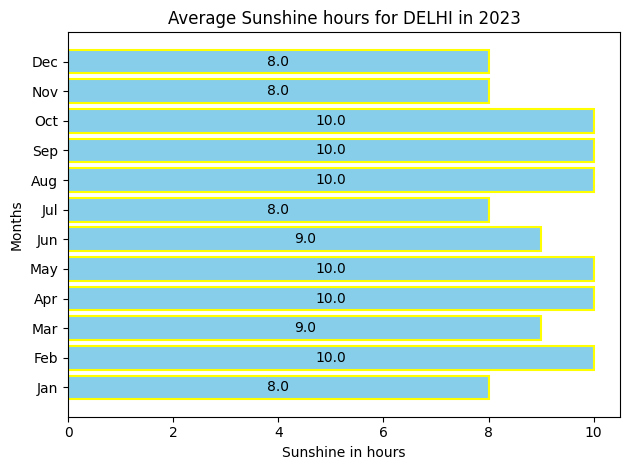

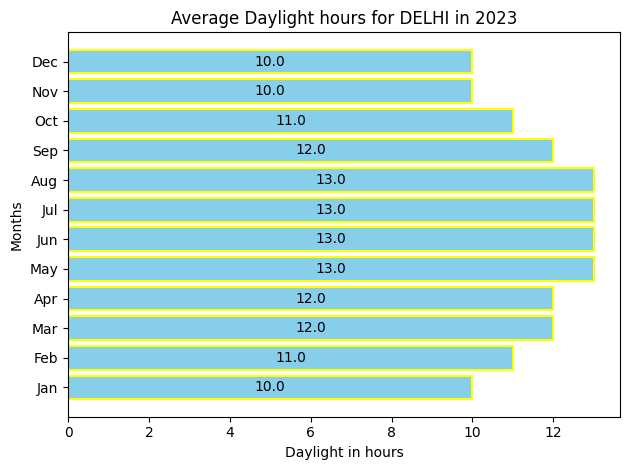

In [34]:
def createBarhChart(values, quantityName, place):
    months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
    x = values

    barplot = plt.barh(months, x, color="skyblue", linewidth=1.5, edgecolor="yellow")
    plt.xlabel(f"{quantityName} in hours")
    plt.ylabel("Months")
    plt.bar_label(barplot, labels=x, label_type="center")
    plt.title(f"Average {quantityName} hours for {place} in 2023")

    plt.tight_layout()
    plt.show()

def daylightAndSunshineDurationsDelhi():
    url = "https://archive-api.open-meteo.com/v1/archive?latitude=28.6519&longitude=77.2315&start_date=2023-01-01&end_date=2023-12-31&daily=daylight_duration,sunshine_duration&timezone=Asia%2FBangkok"

    response = requests.get(url).json()
    df = pd.DataFrame(response["daily"])
    avgSunshine = []
    avgDaylight = []

    for i in range(len(endTime)):
        monthLogic = (df["time"] >= startTime[i]) & (df["time"] <= endTime[i])
        monthData = df[monthLogic][["daylight_duration","sunshine_duration"]]

        stats = monthData.describe().round(3)
        daylight = ((stats.loc["mean", "daylight_duration"])//60)//60
        sunshine = ((stats.loc["mean", "sunshine_duration"])//60)//60
        
        avgSunshine.append(sunshine)
        avgDaylight.append(daylight)

    return avgSunshine, avgDaylight

sunshine,daylight = daylightAndSunshineDurationsDelhi()
createBarhChart(sunshine, "Sunshine", "DELHI")
createBarhChart(daylight, "Daylight", "DELHI")

## **Insights**
#### **1. Sunshine Hours (Top Graph)**
- **Peak Sunshine (10 hours/day)** → **Feb, Mar, Apr, May, Sep, Oct**.
- **Lowest Sunshine (8 hours/day)** → **Jan, Jul, Nov, Dec**.
- **Moderate Sunshine (9 hours/day)** → **Jun, Mar**.
- **Sunshine remains stable (~8-10 hrs) throughout the year** with slight dips in monsoon months (Jul-Aug).

#### **2. Daylight Hours (Bottom Graph)**
- **Longest daylight (13 hours/day)** → **May to July**.
- **Shortest daylight (10 hours/day)** → **Dec, Jan**.
- **Steady Increase:** **From Jan (10 hrs) to June (13 hrs)**.
- **Steady Decrease:** **From July (13 hrs) to Dec (10 hrs)**.
- **Daylight duration closely follows seasonal variations**, with maximum in summer and minimum in winter.


## **g. Sunshine and Daylight Durations in Chennai(2023)**

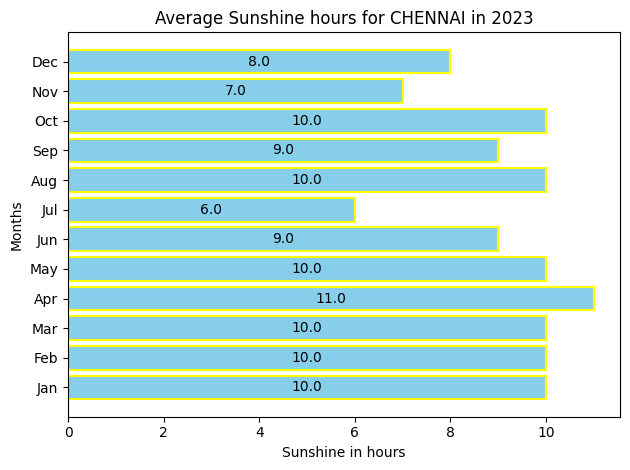

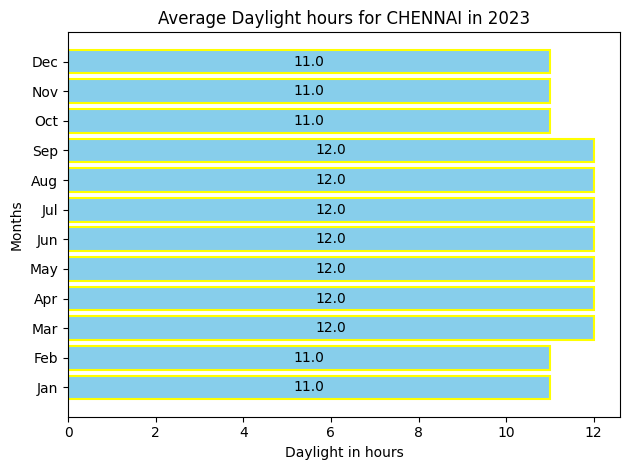

In [35]:
def daylightAndSunshineDurationsChennai():
    url = "https://archive-api.open-meteo.com/v1/archive?latitude=13.0878&longitude=80.2785&start_date=2023-01-01&end_date=2023-12-31&daily=daylight_duration,sunshine_duration&timezone=Asia%2FBangkok"

    response = requests.get(url).json()
    df = pd.DataFrame(response["daily"])
    avgSunshine = []
    avgDaylight = []


    for i in range(len(endTime)):
        monthLogic = (df["time"] >= startTime[i]) & (df["time"] <= endTime[i])
        monthData = df[monthLogic][["daylight_duration","sunshine_duration"]]

        stats = monthData.describe().round(3)
        daylight = ((stats.loc["mean", "daylight_duration"])//60)//60
        sunshine = ((stats.loc["mean", "sunshine_duration"])//60)//60
        
        avgSunshine.append(sunshine)
        avgDaylight.append(daylight)

    return avgSunshine, avgDaylight

sunshine2, daylight2 = daylightAndSunshineDurationsChennai()
createBarhChart(sunshine2, "Sunshine", "CHENNAI")
createBarhChart(daylight2, "Daylight", "CHENNAI")


## **Insights**

#### **1. Sunshine Hours**  
- **Delhi** has relatively consistent sunshine (~8-10 hrs) throughout the year.  
- **Chennai** has **higher sunshine in summer (Apr: 11 hrs, May: 10 hrs)** but experiences a **monsoon dip in July (6 hrs)**.  
- **Chennai's sunshine is more variable** compared to Delhi, affected by seasonal rainfall.  

#### **2. Daylight Hours**  
- **Delhi** shows a **clear seasonal variation**, peaking at **13 hrs in May-July** and dropping to **10 hrs in Dec-Jan**.  
- **Chennai** has a **more stable daylight duration (11-12 hrs year-round)**, due to its tropical location closer to the equator.  

### **Key Takeaways:**  
- **Delhi experiences stronger seasonal daylight variation.**  
- **Chennai gets less sunshine in monsoons but more consistent daylight hours.**  
- **Both cities get similar peak sunshine (~10 hrs), but Chennai peaks in April while Delhi peaks in multiple months.**  

## **h. Sunrise and Sunset Times in Delhi(2023)**

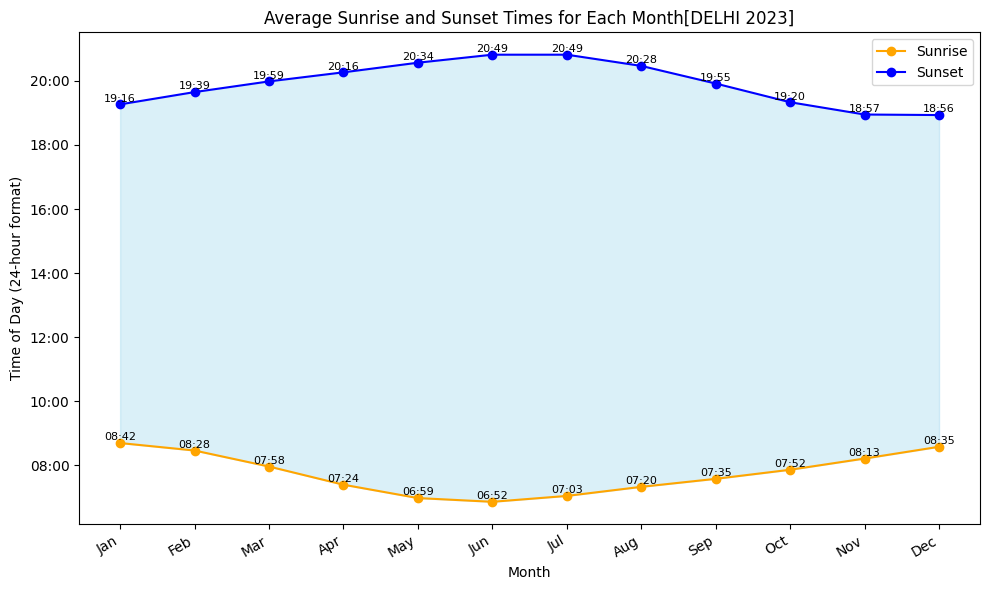

In [38]:
def sunriseSunsetPlot(sunrise,sunset,place):
    months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
    sunriseTimes = sunrise
    sunsetTimes = sunset
    sunrise = [datetime.combine(datetime(1970, 1, 1), t) for t in sunriseTimes]
    sunset = [datetime.combine(datetime(1970, 1, 1), t) for t in sunsetTimes]

    plt.figure(figsize=(10, 6))

    plt.plot(months, sunrise, label="Sunrise", color='orange', marker='o')
    for i,x in enumerate(sunrise):
        plt.text(i,x+timedelta(minutes=5),f"{x.strftime('%H:%M')}", fontsize=8, ha="center")
    
    plt.plot(months, sunset, label="Sunset", color='blue', marker='o')
    for i,x in enumerate(sunset):
        plt.text(i,x+timedelta(minutes=5),f"{x.strftime('%H:%M')}", fontsize=8, ha="center")

    # Fill between sunrise and sunset to show daylight hours
    plt.fill_between(months, sunrise, sunset, color='skyblue', alpha=0.3)

    # Formatting the y-axis to show time in HH:MM format
    plt.gca().yaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%H:%M'))

    # Rotate x-axis labels for better readability
    plt.gcf().autofmt_xdate()

    
    plt.xlabel("Month")
    plt.ylabel("Time of Day (24-hour format)")
    plt.title(f"Average Sunrise and Sunset Times for Each Month[{place} 2023]")
    plt.legend()

    plt.tight_layout()
    plt.show()


def sunriseAndSunsetDelhi():
    url = "https://archive-api.open-meteo.com/v1/archive?latitude=28.6519&longitude=77.2315&start_date=2023-01-01&end_date=2023-12-31&daily=sunrise,sunset&timezone=Asia%2FBangkok"

    response = requests.get(url).json()
    df = pd.DataFrame(response["daily"])
    sunrises = []
    sunsets = []

    for i in range(len(endTime)):
        monthLogic = (df["time"] >= startTime[i]) & (df["time"] <= endTime[i])
        data = df[monthLogic][["sunrise","sunset"]]
        sunriseTimes = pd.to_datetime(data["sunrise"]).dt.time
        sunsetTimes = pd.to_datetime(data["sunset"]).dt.time

        # converting to seconds
        sunrise_seconds = sunriseTimes.apply(lambda x: x.hour * 3600 + x.minute*60 + x.second)
        sunset_seconds = sunsetTimes.apply(lambda x: x.hour * 3600 + x.minute*60 + x.second)

        #mean
        avgSunrise = sunrise_seconds.mean()
        avgSunset = sunset_seconds.mean()

        # converting to time object
        avgSunriseTimdelta = timedelta(seconds=avgSunrise)
        avgSunsetTimedelta = timedelta(seconds=avgSunset)

        # adding with base time
        basetime = datetime(1970,1,1)
        avgSunriseTime = basetime + avgSunriseTimdelta
        avgSunsetTime = basetime + avgSunsetTimedelta

        #remove seconds and microseconds
        avgSunriseTime = avgSunriseTime.time().replace(microsecond=0, second=0)
        avgSunsetTime = avgSunsetTime.time().replace(microsecond=0, second=0)

        sunrises.append(avgSunriseTime)
        sunsets.append(avgSunsetTime)

    return sunrises, sunsets


sunrise, sunset = sunriseAndSunsetDelhi()
sunriseSunsetPlot(sunrise, sunset, "DELHI")

## **Insights**

This graph represents the **average sunrise and sunset times for each month in Delhi for 2023** in **24-hour format**.

### **1. Sunrise Trends (Orange Line)**
- The **earliest sunrise** occurs in **June (06:52 AM)**.
- The **latest sunrise** occurs in **January (08:42 AM)**.
- Sunrise time **decreases from January to June**, reaching its earliest point, then **gradually increases from July to December**.

### **2. Sunset Trends (Blue Line)**
- The **latest sunset** occurs in **June and July (20:49 PM)**.
- The **earliest sunset** occurs in **December (18:56 PM)**.
- Sunset time **increases from January to June**, then **declines toward December**.

### **3. Comparison with Chennai**
- **Delhi has more variation in daylight duration** compared to Chennai. This is because Delhi is farther from the equator, so it experiences **longer summer days and shorter winter days**.
- Chennai's **sunrise and sunset times remain relatively stable**, whereas **Delhi has a more noticeable shift**.
- **Delhi's winter sunrises are significantly later** than Chennai's, and sunsets are earlier.

### **4. Daylight Duration Changes**
- **Longest days in June-July (~14 hours of daylight)**.
- **Shortest days in December-January (~10 hours of daylight)**.
- The seasonal variation in daylight is more prominent in Delhi due to its latitude.

## **i. Sunrise and Sunset Times in Chennai(2023)**

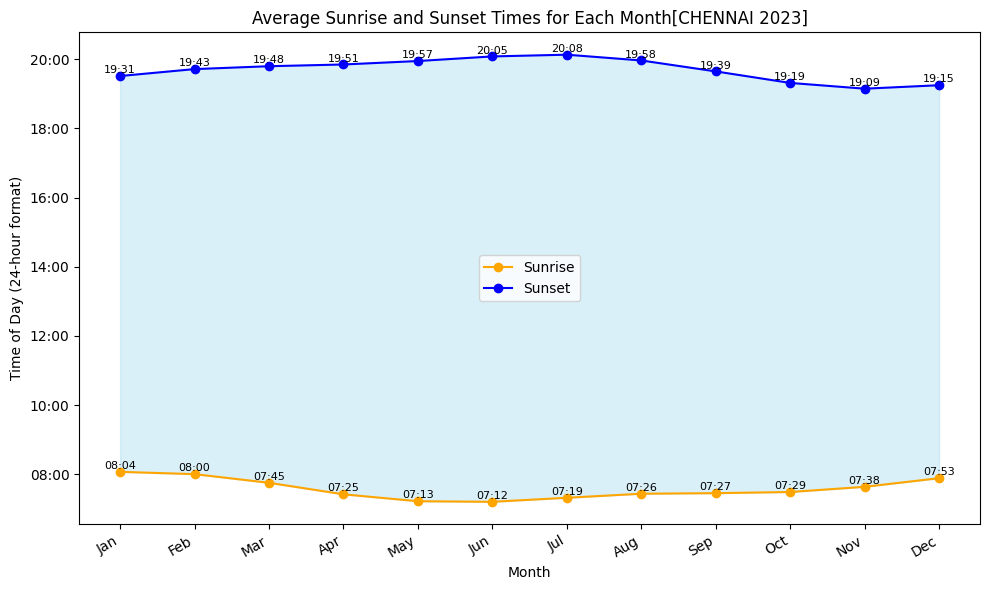

In [39]:
def sunriseAndSunsetChennai():
    url = "https://archive-api.open-meteo.com/v1/archive?latitude=13.0878&longitude=80.2785&start_date=2023-01-01&end_date=2023-12-31&daily=sunrise,sunset&timezone=Asia%2FBangkok"

    response = requests.get(url).json()
    df = pd.DataFrame(response["daily"])
    sunrises = []
    sunsets = []
    
    for i in range(len(endTime)):
        monthLogic = (df["time"] >= startTime[i]) & (df["time"] <= endTime[i])
        data = df[monthLogic][["sunrise","sunset"]]
        sunriseTimes = pd.to_datetime(data["sunrise"]).dt.time
        sunsetTimes = pd.to_datetime(data["sunset"]).dt.time

        # converting to seconds
        sunrise_seconds = sunriseTimes.apply(lambda x: x.hour * 3600 + x.minute*60 + x.second)
        sunset_seconds = sunsetTimes.apply(lambda x: x.hour * 3600 + x.minute*60 + x.second)

        #mean
        avgSunrise = sunrise_seconds.mean()
        avgSunset = sunset_seconds.mean()

        # converting to time object
        avgSunriseTimdelta = timedelta(seconds=avgSunrise)
        avgSunsetTimedelta = timedelta(seconds=avgSunset)

        # adding with base time
        basetime = datetime(1970,1,1)
        avgSunriseTime = basetime + avgSunriseTimdelta
        avgSunsetTime = basetime + avgSunsetTimedelta

        #remove seconds and microseconds
        avgSunriseTime = avgSunriseTime.time().replace(microsecond=0, second=0)
        avgSunsetTime = avgSunsetTime.time().replace(microsecond=0, second=0)

        sunrises.append(avgSunriseTime)
        sunsets.append(avgSunsetTime)

    return sunrises, sunsets

sunriseChen, sunsetChen = sunriseAndSunsetChennai()
sunriseSunsetPlot(sunriseChen, sunsetChen, "CHENNAI")

## **Insights**

This graph presents the **average sunrise and sunset times for each month in Chennai for 2023**, using a **24-hour format**.
1. **Sunrise Trends (Orange Line)**  
   - The earliest sunrise occurs in **June (07:12 AM)**.  
   - The latest sunrise happens in **January (08:04 AM)**.  
   - Sunrise time generally **decreases from January to June** and then **gradually increases until December**.  

2. **Sunset Trends (Blue Line)**  
   - The latest sunset occurs in **July (20:08 PM)**.  
   - The earliest sunset happens in **November (19:09 PM)**.  
   - The sunset time **increases from January to July**, then **decreases gradually toward December**.  

3. **Daylight Duration**  
   - The longest days occur **around June and July**, where the sunrise is early, and sunset is late.  
   - The shortest days occur in **December and January**, where the sunrise is later, and sunset happens earlier.  

4. **Seasonal Pattern**  
   - This pattern is typical for tropical regions like Chennai, where there are **minor variations in daylight duration** throughout the year compared to higher latitudes.  

## **j. Maximum and Minimum Temperatures per month in Delhi(2023)**

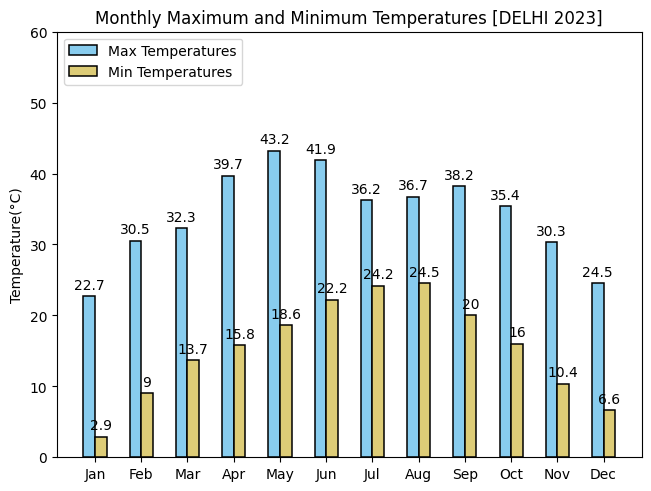

In [40]:
def dualBarPlot(maximum, minimum, place):
    maxTemps = maximum
    minTemps = minimum
    months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

    width = 0.25  # the width of the bars
    x = np.arange(len(months))
    multiplier = 0
    colors = ["#88CCEE", "#DDCC77"]

    fig, ax = plt.subplots(layout='constrained')

    for measurement,label,color in zip([maxTemps, minTemps], ["Max Temperatures", "Min Temperatures"], colors):
        offset = width * multiplier
        rects = ax.bar(x + offset, measurement, width, label=label, color=color, edgecolor="black", linewidth=1.1)
        ax.bar_label(rects, padding=3)
        multiplier += 1

  
    ax.set_ylabel('Temperature(°C)')
    ax.set_title(f"Monthly Maximum and Minimum Temperatures [{place} 2023]")
    ax.set_xticks(x + width / 2, months)
    ax.legend(loc='upper left')
    ax.set_ylim(0, 60)

    plt.show()

def maxMinTempDelhi():
    url="https://archive-api.open-meteo.com/v1/archive?latitude=28.6519&longitude=77.2315&start_date=2023-01-01&end_date=2023-12-31&daily=temperature_2m_max,temperature_2m_min&timezone=Asia%2FBangkok"
    response = requests.get(url).json()
    df = pd.DataFrame(response["daily"])
    maxTemps = []
    minTemps = []


    for i in range(len(endTime)):

        logic = (df["time"] >= startTime[i]) & (df["time"] <= endTime[i])
        temps = df[logic][["temperature_2m_max", "temperature_2m_min"]]
        stats = temps.describe()
        max = stats.loc["max"]["temperature_2m_max"]
        min = stats.loc["min"]["temperature_2m_min"]

        maxTemps.append(max)
        minTemps.append(min)

    return minTemps, maxTemps

minTemps, maxTemps = maxMinTempDelhi()
dualBarPlot(maxTemps, minTemps, "DELHI")

## **Insights**

#### **1. Temperature Trends Over the Year**
- **Winter Months (January and February):**
  - **Minimum temperatures** were the lowest, with **January** recording the coldest night at **2.9°C**.
  - **Maximum temperatures** during these months ranged between **22.7°C to 32.3°C**, indicating cool days.

- **Summer Months (March to June):**
  - **Maximum temperatures** peaked during these months, with **May** recording the highest temperature of **43.2°C**.
  - **Minimum temperatures** also increased, ranging from **18.6°C to 26.7°C**, indicating warm nights.

- **Monsoon Season (July to September):**
  - A noticeable drop in **maximum temperatures** was observed, with the lowest being **30.3°C** in **September**.
  - **Minimum temperatures** during this period ranged between **24.2°C to 26.7°C**, reflecting humid and warm nights.

- **Post-Monsoon and Early Winter (October to December):**
  - **Maximum temperatures** gradually decreased from **38.2°C in October** to **24.5°C in December**.
  - **Minimum temperatures** dropped significantly, with **December** recording **6.6°C**, indicating the onset of winter.

---

#### **2. Temperature Extremes**
- **Highest Maximum Temperature:** **43.2°C** in **May**.
- **Lowest Maximum Temperature:** **24.5°C** in **December**.
- **Highest Minimum Temperature:** **26.7°C** in **June**.
- **Lowest Minimum Temperature:** **2.9°C** in **January**.


#### **5. Implications**
- The data highlights Delhi's **extreme continental climate**, with **hot summers** and **cold winters**.
- The **monsoon season** brings relief from the heat but also increases humidity, leading to warm nights.
- The **significant temperature variations** between seasons can impact daily life, agriculture, and energy consumption in the region.

---

## **k. Maximum and Minimum Temperatures per month in Chennai(2023)**

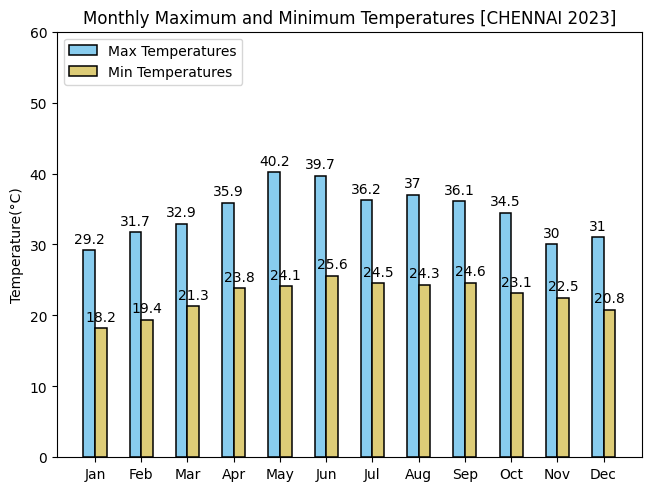

In [41]:
def maxMinTempChennai():
    url="https://archive-api.open-meteo.com/v1/archive?latitude=13.0878&longitude=80.2785&start_date=2023-01-01&end_date=2023-12-31&daily=temperature_2m_max,temperature_2m_min&timezone=Asia%2FBangkok"
    response = requests.get(url).json()
    df = pd.DataFrame(response["daily"])
    maxTemps = []
    minTemps = []

    for i in range(len(endTime)):

        logic = (df["time"] >= startTime[i]) & (df["time"] <= endTime[i])
        temps = df[logic][["temperature_2m_max", "temperature_2m_min"]]
        stats = temps.describe()
        max = stats.loc["max"]["temperature_2m_max"]
        min = stats.loc["min"]["temperature_2m_min"]

        maxTemps.append(max)
        minTemps.append(min)

    return minTemps, maxTemps

minTempsChen,maxTempsChen = maxMinTempChennai()
dualBarPlot(maxTempsChen, minTempsChen, "CHENNAI")

### **Insights**

#### **1. Temperature Trends Over the Year**
- **Peak Summer Months (March to May):**
  - The **maximum temperatures** were highest during these months, with **March** recording the highest temperature of **39.7°C**.
  - **Minimum temperatures** also remained relatively high, ranging between **24.5°C to 28.1°C**, indicating warm nights.

- **Monsoon Season (June to September):**
  - A noticeable drop in **maximum temperatures** was observed, with the lowest being **29.2°C** in **June**.
  - **Minimum temperatures** during this period ranged between **22.5°C to 24.6°C**, reflecting cooler nights due to rainfall.

- **Post-Monsoon and Winter Months (October to February):**
  - **Maximum temperatures** gradually increased from **30°C in October** to **36.2°C in December**.
  - **Minimum temperatures** remained stable, averaging around **24°C**, indicating mild winters in Chennai.

---

#### **2. Temperature Extremes**
- **Highest Maximum Temperature:** **39.7°C** in **March**.
- **Lowest Maximum Temperature:** **29.2°C** in **June**.
- **Highest Minimum Temperature:** **28.1°C** in **May**.
- **Lowest Minimum Temperature:** **18.2°C** in **January**.
  
---

#### **5. Implications**
- The data highlights Chennai's **tropical climate**, with **high temperatures** throughout the year and **mild seasonal variations**.
- The **monsoon season** brings relief from the heat, with cooler temperatures and increased humidity.
- The **stable minimum temperatures** indicate that Chennai does not experience harsh winters, making it a warm city year-round.

# **Conclusion**

## **Side-by-Side Comparison: Delhi vs. Chennai Climate Trends**  

| Climate Factor   | **Delhi (Inland, North India)** | **Chennai (Coastal, South India)** |  
|-----------------|--------------------------------|----------------------------------|  
| **Temperature Range** | **Extreme (11°C - 31°C, ~20°C variation)** | **Stable (25°C - 31°C, ~6°C variation)** |  
| **Hottest Month** | **June (~31°C, dry heat)** | **May (~30.15°C, humid heat)** |  
| **Coldest Month** | **January (~11.74°C, dry cold)** | **January (~24.8°C, still warm)** |  
| **Humidity Levels** | **Varies (65-80%)** | **Consistently high (75-85%)** |  
| **Monsoon Impact** | **Southwest Monsoon (July-Sep)** → Higher humidity | **Northeast Monsoon (Oct-Dec)** → Peak humidity |  
| **Summer Heat** | **Dry and intense (~31°C in June)** | **Humid and hot (~30.15°C in May)** |  
| **Winter** | **Cold (~11-14°C)** | **No real winter (~25°C)** |  

### **Key Takeaways from Comparison**  
✅ **Delhi has extreme temperature swings**, while **Chennai is stable but humid**.  
✅ **Humidity plays a major role**—Chennai feels hotter despite similar temperatures.  
✅ **Monsoons affect both cities differently**—Delhi cools down post-monsoon, while Chennai remains humid.  

---

### **Energy Consumption & Comfort**  
- **Delhi** → Needs **heaters in winter and ACs in summer**, leading to **high energy costs**.  
- **Chennai** → **Less seasonal variation**, but **continuous use of fans/ACs due to humidity**.  

### **Travel & Tourism Recommendations**  
- **Best time to visit Delhi** → **October to March** (pleasant temperatures).  
- **Best time to visit Chennai** → **December to February** (relatively cooler and less humid).  

### **Urban Planning & Infrastructure**  
- **Delhi’s extreme shifts** → Requires **better insulation, heating, and cooling systems**.  
- **Chennai’s humidity** → Requires **improved ventilation, cooling solutions, and drainage** for monsoons.  

---